# AMR Drug Repurposing — 03: Publication-Ready Figures

Re-generates all figures with journal-quality settings: 300 DPI, Arial/Helvetica fonts, Nature-style colour palette, proper axis labels, and scalable vector exports (SVG + PNG).

## Paths

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent
# When running from notebooks/ dir, parent is the project root
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR  = PROJECT_ROOT / 'data'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
FIG_DIR   = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, CKPT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"CKPT_DIR     : {CKPT_DIR}")
print(f"FIG_DIR      : {FIG_DIR}")

PROJECT_ROOT : /Users/jubayer/Projects/amr_drug_repurposing
DATA_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/data
CKPT_DIR     : /Users/jubayer/Projects/amr_drug_repurposing/checkpoints
FIG_DIR      : /Users/jubayer/Projects/amr_drug_repurposing/figures


## Imports & global matplotlib style

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# ── Journal-quality matplotlib defaults (Nature / Cell style) ─────────────────
plt.rcParams.update({
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':             7,
    'axes.titlesize':        7,
    'axes.labelsize':        7,
    'xtick.labelsize':       6,
    'ytick.labelsize':       6,
    'legend.fontsize':       6,
    'legend.title_fontsize': 6,
    'legend.frameon':        False,
    'legend.borderpad':      0.3,
    'legend.labelspacing':   0.25,
    'legend.handlelength':   1.5,
    'legend.handletextpad':  0.4,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3.0,
    'ytick.major.size':      3.0,
    'xtick.minor.visible':   False,
    'ytick.minor.visible':   False,
    'lines.linewidth':       1.25,
    'patch.linewidth':       0.5,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.grid':             False,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
    'savefig.pad_inches':    0.04,
    'pdf.fonttype':          42,   # embed fonts (required by many journals)
    'ps.fonttype':           42,
})

# Nature-style colour palette
C = {
    'active':   '#2166AC',   # blue
    'inactive': '#B2182B',   # red
    'mlp':      '#1B7837',   # dark green
    'rf':       '#762A83',   # purple
    'ensemble': '#D6604D',   # salmon-orange
    'neutral':  '#969696',   # grey
    'light':    '#D1E5F0',   # light blue fill
    'amber':    '#F4A582',   # light salmon
}

PANEL_KW = dict(fontsize=9, fontweight='bold', va='top')  # panel letter style

def add_panel_label(ax, letter, x=-0.14, y=1.05):
    ax.text(x, y, letter, transform=ax.transAxes, **PANEL_KW)

def save_fig(fig, name):
    for fmt in ['png', 'svg']:
        fig.savefig(FIG_DIR / f"{name}.{fmt}", dpi=300,
                    bbox_inches='tight', pad_inches=0.04)
    print(f"  Saved: {name}.png / .svg")

# Figure name registry for reference
MAIN_FIGS  = {}
SUPP_FIGS  = {}
print("Style configured. Ready.")

Style configured. Ready.


## Load saved artefacts

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
import pickle, gc, time
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('mps'  if torch.backends.mps.is_available()
                  else 'cuda' if torch.cuda.is_available() else 'cpu')

def free_memory(*objs):
    for o in objs:
        try: del o
        except: pass
    gc.collect()
    if torch.backends.mps.is_available():   torch.mps.empty_cache()
    elif torch.cuda.is_available():          torch.cuda.empty_cache()

X        = np.load(DATA_DIR / 'X_ecfp.npy')
y        = np.load(DATA_DIR / 'y_labels.npy')
df_clean = pd.read_csv(DATA_DIR / 'eskape_clean.csv')

# ── Molecule-level split — mirrors nb02 exactly (zero molecule overlap) ───────
# Load masks saved by nb02; fall back to recomputing if masks not present.
_train_mask_path = DATA_DIR / 'train_mask.npy'
_test_mask_path  = DATA_DIR / 'test_mask.npy'

if _train_mask_path.exists() and _test_mask_path.exists():
    train_mask = np.load(_train_mask_path)
    test_mask  = np.load(_test_mask_path)
    print("Loaded molecule-level split masks from nb02.")
else:
    # Recompute molecule-level split (same logic as nb02 cell 6)
    _valid_mask = df_clean['canonical_smiles'].apply(
        lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)
    df_fp = df_clean[_valid_mask].reset_index(drop=True)
    mol_label = (df_fp.groupby('molecule_chembl_id')['active']
                   .agg(lambda x: int(x.mean() >= 0.5)))
    mol_ids = mol_label.index.to_numpy().astype(str)
    mol_y   = mol_label.to_numpy().astype(int)
    train_mols, test_mols = train_test_split(
        mol_ids, test_size=0.2, random_state=SEED, stratify=mol_y)
    train_mask = df_fp['molecule_chembl_id'].astype(str).isin(set(train_mols)).values
    test_mask  = df_fp['molecule_chembl_id'].astype(str).isin(set(test_mols)).values
    np.save(_train_mask_path, train_mask)
    np.save(_test_mask_path,  test_mask)
    print("Recomputed and saved molecule-level split masks.")

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")
assert len(set(np.where(train_mask)[0]) & set(np.where(test_mask)[0])) == 0

# Re-train RF on molecule-level split (matches nb02)
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

# Load MLP
class FingerprintDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class AntibacterialMLP(nn.Module):
    def __init__(self, input_dim=2048, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),       nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),        nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),        nn.BatchNorm1d(128),  nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(128, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

model = AntibacterialMLP().to(device)
ckpt  = torch.load(CKPT_DIR / 'best_mlp.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

test_loader = DataLoader(FingerprintDataset(X_test, y_test),
                         batch_size=512, shuffle=False, num_workers=0)
all_prob = []
with torch.no_grad():
    for xb, _ in test_loader:
        logits = model(xb.to(device)).cpu().numpy()
        all_prob.extend(1 / (1 + np.exp(-logits)))

mlp_prob = np.array(all_prob)
mlp_pred = (mlp_prob >= 0.5).astype(int)

from sklearn.metrics import roc_auc_score, average_precision_score
mlp_roc = roc_auc_score(y_test, mlp_prob)
mlp_prc = average_precision_score(y_test, mlp_prob)
rf_roc  = roc_auc_score(y_test, rf_prob)
rf_prc  = average_precision_score(y_test, rf_prob)

print(f"MLP  ROC-AUC: {mlp_roc:.4f}  PRC-AUC: {mlp_prc:.4f}")
print(f"RF   ROC-AUC: {rf_roc:.4f}  PRC-AUC: {rf_prc:.4f}")

# Load repurposing candidates
df_results = pd.read_csv(DATA_DIR / 'repurposing_candidates.csv')

# Safety re-filter (antibiotic keyword check on loaded candidates)
_abx_kw = ['floxacin','oxacin','cillin','cyclin','mycin','penem','bactam',
            'cef','ceph','carbef','carbaceph','loracarbef',
            'sulfa','trimethoprim','isoniazid','rifamp','ethambutol','metronidazole',
            'vancomycin','linezolid','daptomycin','colistin','polymyxin',
            'chloramphenicol','nitrofurantoin','clindamycin','azithromycin',
            'clarithromycin','erythromycin','tobramycin','gentamicin','amikacin',
            'streptomycin','tetracycline','doxycycline','minocycline','tigecycline',
            'meropenem','imipenem','aztreonam','quinupristin','mupirocin',
            'bacitracin','fosfomycin','rifaximin']
_abx_mask = df_results['drug_name'].fillna('').str.lower().apply(
    lambda x: any(kw in x for kw in _abx_kw))
df_results = df_results[~_abx_mask].reset_index(drop=True)

if 'drug_like' in df_results.columns:
    df_druglike = df_results[df_results['drug_like'] == 1].copy()
else:
    df_druglike = df_results.copy()

org_csv = DATA_DIR / 'organism_rf_results.csv'
df_org  = pd.read_csv(org_csv) if org_csv.exists() else pd.DataFrame()

print(f"Repurposing candidates (antibiotic-excluded): {len(df_results):,}")
print(f"Drug-like candidates                        : {len(df_druglike):,}")
if not df_org.empty:
    print(f"Organism models available                   : {df_org['status'].eq('trained').sum()}")

Loaded molecule-level split masks from nb02.
Train: 57,341 rows  |  Test: 14,282 rows
Train positive rate: 0.431  |  Test: 0.430
MLP  ROC-AUC: 0.9693  PRC-AUC: 0.9601
RF   ROC-AUC: 0.9206  PRC-AUC: 0.9034
Repurposing candidates (antibiotic-excluded): 2,659
Drug-like candidates                        : 1,700
Organism models available                   : 8


## Figure 1 — Dataset overview

**Main figure.** ESKAPE pathogen bioactivity dataset characteristics.

  Saved: figure_1_dataset_overview.png / .svg


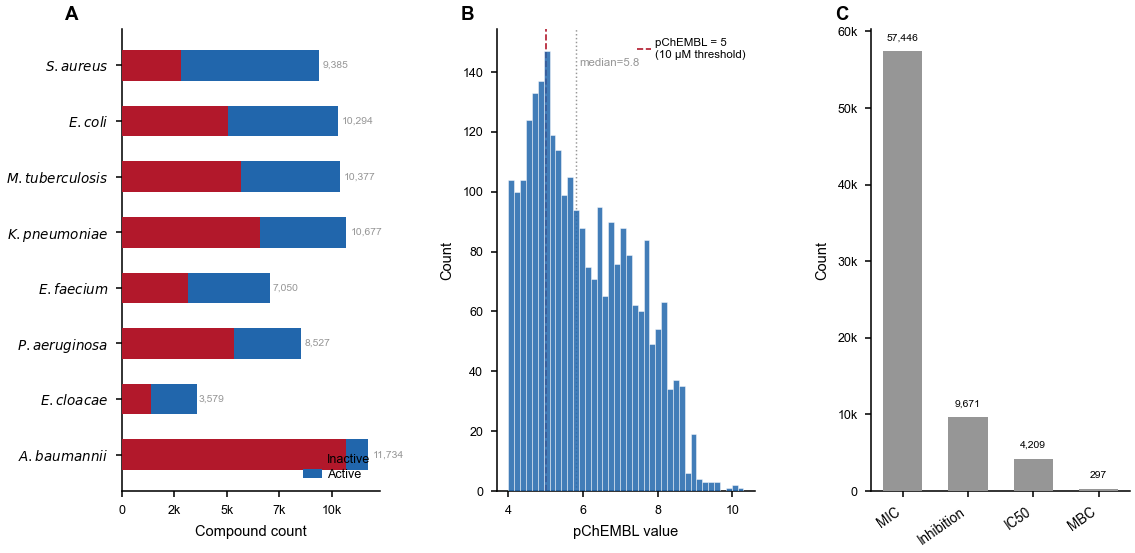

In [4]:
# ── Figure 1 — Dataset overview ─────────────────────────────────────────────
def _abbrev(name):
    parts = name.split()
    return f"$\\it{{{parts[0][0]}. {parts[1]}}}$" if len(parts) >= 2 else name

org_counts = (df_clean.groupby(['target_organism', 'active'])
                       .size().unstack(fill_value=0)
                       .rename(columns={0: 'Inactive', 1: 'Active'}))
org_counts.index  = [_abbrev(x) for x in org_counts.index]
org_sorted        = org_counts.sort_values('Active', ascending=True)
n_org             = len(org_sorted)

fig = plt.figure(figsize=(7.0, 4.0))
gs  = fig.add_gridspec(1, 3, wspace=0.45, left=0.02, right=0.98)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel A: class balance per organism ──────────────────────────────────────
bar_h   = 0.55
y_pos   = np.arange(n_org)
ax1.barh(y_pos, org_sorted['Inactive'], height=bar_h,
         color=C['inactive'], label='Inactive', zorder=3)
ax1.barh(y_pos, org_sorted['Active'],   height=bar_h,
         left=org_sorted['Inactive'], color=C['active'], label='Active', zorder=3)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(org_sorted.index, fontsize=6.5)
ax1.set_xlabel('Compound count')
ax1.legend(loc='lower right', fontsize=6)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x>=1000 else str(int(x))))
for i, (_, row) in enumerate(org_sorted.iterrows()):
    total = row['Inactive'] + row['Active']
    ax1.text(total + total * 0.02, i, f'{total:,}', va='center', fontsize=5, color=C['neutral'])
add_panel_label(ax1, 'A', x=-0.22)

# ── Panel B: pChEMBL value distribution ──────────────────────────────────────
pchem = df_clean['pchembl_value'].dropna().astype(float)
if len(pchem) > 100:
    ax2.hist(pchem, bins=40, color=C['active'], edgecolor='white', linewidth=0.25, alpha=0.85, zorder=3)
    # pChEMBL = -log10(activity in M); threshold 5 = 10 uM (binarisation cutoff)
    ax2.axvline(5, color=C['inactive'], ls='--', lw=0.8,
                label='pChEMBL = 5\n(10 μM threshold)')
    ax2.set_xlabel('pChEMBL value')
    ax2.legend(fontsize=5.5, handlelength=1.2)
    med = pchem.median()
    ax2.axvline(med, color=C['neutral'], ls=':', lw=0.7)
    # Place median annotation after all elements so ylim is final
    ax2.autoscale(enable=True, axis='y')
    _ymax = ax2.get_ylim()[1]
    ax2.text(med + 0.1, _ymax * 0.92, f'median={med:.1f}', fontsize=5.5, color=C['neutral'])
else:
    log_vals = np.log10(df_clean['value_uM'].clip(1e-3, 1e5))
    ax2.hist(log_vals, bins=40, color=C['active'], edgecolor='white', linewidth=0.25, alpha=0.85)
    ax2.set_xlabel('log₁₀(activity value, μM)')
ax2.set_ylabel('Count')
add_panel_label(ax2, 'B')

# ── Panel C: assay type ───────────────────────────────────────────────────────
stype = df_clean['standard_type'].value_counts().head(6)
bars  = ax3.bar(np.arange(len(stype)), stype.values,
                color=C['neutral'], edgecolor='none', width=0.6, zorder=3)
ax3.set_xticks(np.arange(len(stype)))
ax3.set_xticklabels(stype.index, rotation=35, ha='right', fontsize=6.5)
ax3.set_ylabel('Count')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x>=1000 else str(int(x))))
for bar, val in zip(bars, stype.values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + stype.max()*0.02,
             f'{val:,}', ha='center', va='bottom', fontsize=5)
add_panel_label(ax3, 'C')

fig.savefig(FIG_DIR / 'figure_1_dataset_overview.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
fig.savefig(FIG_DIR / 'figure_1_dataset_overview.svg', bbox_inches='tight', pad_inches=0.04)
MAIN_FIGS['Figure 1'] = 'figure_1_dataset_overview'
print("  Saved: figure_1_dataset_overview.png / .svg")
plt.show()

## Figure 2 — Model performance

**Main figure.** Classification performance of Random Forest and deep MLP on the held-out test set (20%, *n* = 14,325).

  Saved: figure_2_model_performance.png / .svg


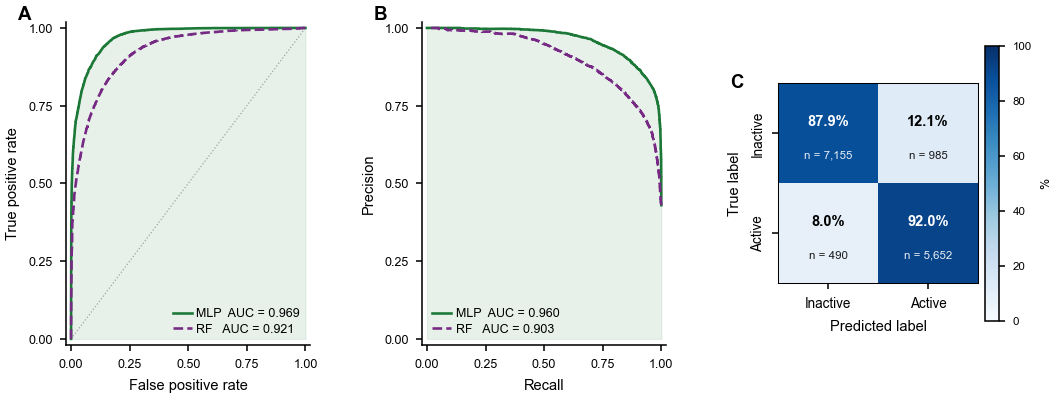

In [5]:
# ── Figure 2 — Model performance ────────────────────────────────────────────
fig = plt.figure(figsize=(7.0, 2.8))
gs  = fig.add_gridspec(1, 3, wspace=0.46, left=0.06, right=0.97)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel A: ROC curve ───────────────────────────────────────────────────────
fpr_m, tpr_m, _ = roc_curve(y_test, mlp_prob)
fpr_r, tpr_r, _ = roc_curve(y_test, rf_prob)
ax1.fill_between(fpr_m, tpr_m, alpha=0.10, color=C['mlp'], zorder=2)
ax1.plot(fpr_m, tpr_m, color=C['mlp'], lw=1.25, zorder=3, label=f'MLP  AUC = {mlp_roc:.3f}')
ax1.plot(fpr_r, tpr_r, color=C['rf'],  lw=1.25, ls='--', zorder=3, label=f'RF   AUC = {rf_roc:.3f}')
ax1.plot([0,1],[0,1], color=C['neutral'], lw=0.6, ls=':', alpha=0.8, zorder=1)
ax1.set_xlabel('False positive rate')
ax1.set_ylabel('True positive rate')
ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(-0.02, 1.02)
ax1.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.legend(loc='lower right')
add_panel_label(ax1, 'A', x=-0.20)

# ── Panel B: Precision-recall curve ─────────────────────────────────────────
prec_m, rec_m, _ = precision_recall_curve(y_test, mlp_prob)
prec_r, rec_r, _ = precision_recall_curve(y_test, rf_prob)
ax2.fill_between(rec_m, prec_m, alpha=0.10, color=C['mlp'], zorder=2)
ax2.plot(rec_m, prec_m, color=C['mlp'], lw=1.25, zorder=3, label=f'MLP  AUC = {mlp_prc:.3f}')
ax2.plot(rec_r, prec_r, color=C['rf'],  lw=1.25, ls='--', zorder=3, label=f'RF   AUC = {rf_prc:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(-0.02, 1.02)
ax2.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.legend(loc='lower left')
add_panel_label(ax2, 'B', x=-0.20)

# ── Panel C: Confusion matrix (MLP, normalised % + raw count) ────────────────
cm_raw = confusion_matrix(y_test, mlp_pred)
cm_pct = cm_raw / cm_raw.sum(axis=1, keepdims=True) * 100

# Restore all spines for heatmap (global rcParams suppresses top/right)
for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

im = ax3.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100, aspect='equal')
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Inactive', 'Active'], fontsize=6.5)
ax3.set_yticklabels(['Inactive', 'Active'], fontsize=6.5, rotation=90, va='center')
ax3.set_xlabel('Predicted label')
ax3.set_ylabel('True label')
# annotate each cell: bold percentage + small raw count
for ii in range(2):
    for jj in range(2):
        txt_col = 'white' if cm_pct[ii, jj] > 60 else 'black'
        ax3.text(jj, ii - 0.12, f'{cm_pct[ii,jj]:.1f}%',
                 ha='center', va='center', fontsize=7, fontweight='bold', color=txt_col)
        ax3.text(jj, ii + 0.22, f'n = {cm_raw[ii,jj]:,}',
                 ha='center', va='center', fontsize=5.5, color=txt_col, alpha=0.9)
cb = fig.colorbar(im, ax=ax3, shrink=0.85, pad=0.03)
cb.set_label('%', fontsize=6)
cb.ax.tick_params(labelsize=5.5)
add_panel_label(ax3, 'C', x=-0.24)

fig.savefig(FIG_DIR / 'figure_2_model_performance.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
fig.savefig(FIG_DIR / 'figure_2_model_performance.svg', bbox_inches='tight', pad_inches=0.04)
MAIN_FIGS['Figure 2'] = 'figure_2_model_performance'
print("  Saved: figure_2_model_performance.png / .svg")
plt.show()

## Figure 3 — Drug repurposing candidates

**Main figure.** Top-ranked FDA-approved non-antibiotic compounds predicted as antibacterial against ESKAPE pathogens (Lipinski Ro5 and Veber-rule compliant).

  Saved: figure_3_repurposing_candidates.png / .svg


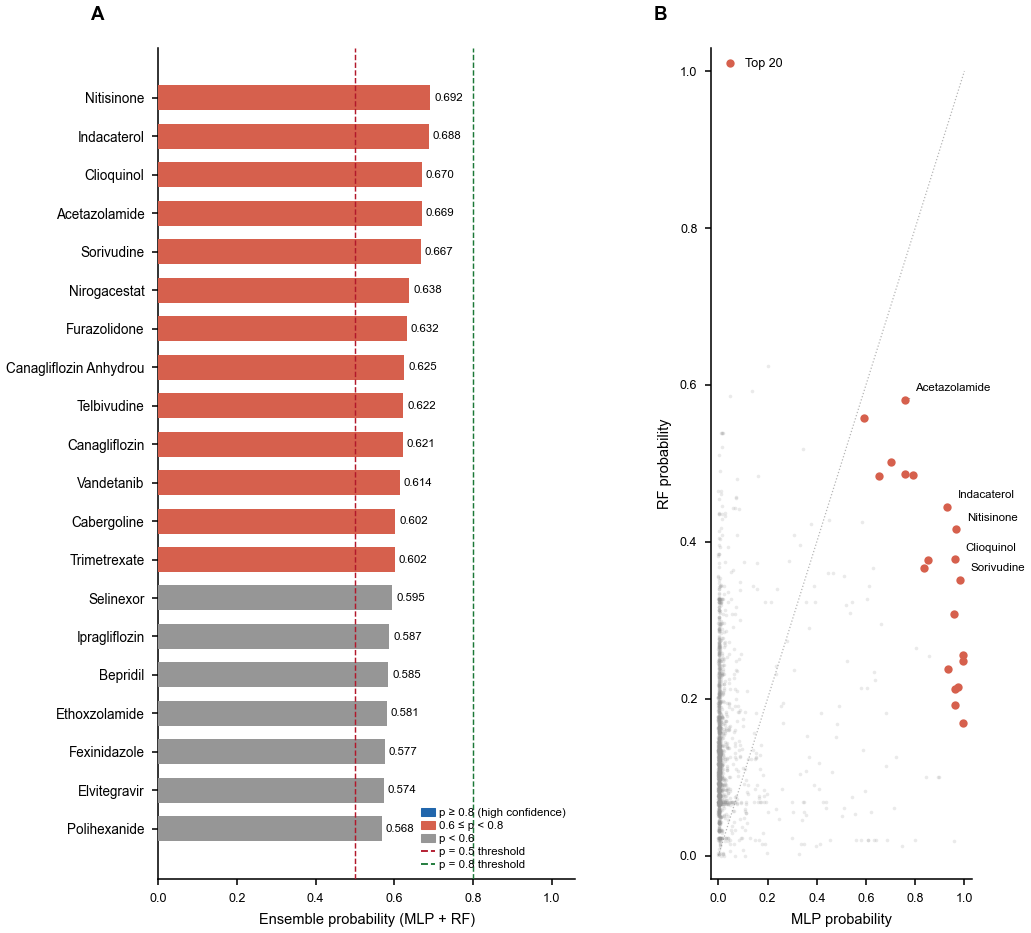

In [6]:
# ── Figure 3 — Drug repurposing candidates ───────────────────────────────────
# Double-column; Panel A taller (0.32 in / drug) to prevent label overlap

N_CAND = 20
top_n  = df_druglike.head(N_CAND).copy()
top_n['label'] = top_n['drug_name'].str.title().str.slice(0, 22)

# Colour bars by ensemble probability (blue = high confidence, orange = moderate, grey = low)
bar_colors = ['#2166AC' if s >= 0.8 else '#D6604D' if s >= 0.6 else '#969696'
              for s in top_n['prob_ensemble']]

panel_h = max(0.32 * N_CAND + 0.8, 5.0)   # at least 0.32 in per drug
fig, axes = plt.subplots(1, 2, figsize=(7.0, panel_h),
                          gridspec_kw={'wspace': 0.40, 'width_ratios': [1.6, 1]})

# ── Panel A: ranked horizontal bar ───────────────────────────────────────────
y_pos  = np.arange(N_CAND)
axes[0].barh(y_pos, top_n['prob_ensemble'], height=0.65,
             color=bar_colors, edgecolor='none', zorder=3)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_n['label'], fontsize=6.5)
axes[0].invert_yaxis()
axes[0].axvline(0.5, color=C['inactive'], ls='--', lw=0.7, zorder=4)
axes[0].axvline(0.8, color=C['mlp'],      ls='--', lw=0.7, zorder=4)
axes[0].set_xlabel('Ensemble probability (MLP + RF)')
axes[0].set_xlim(0, 1.06)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(0.2))

# annotate probability values
for i, (_, row) in enumerate(top_n.iterrows()):
    p = row['prob_ensemble']
    axes[0].text(p + 0.01, i, f'{p:.3f}', va='center', fontsize=5.5,
                 color='white' if p > 0.95 else 'black')

# legend patches
axes[0].legend(handles=[
    mpatches.Patch(color='#2166AC', label='p ≥ 0.8 (high confidence)'),
    mpatches.Patch(color='#D6604D', label='0.6 ≤ p < 0.8'),
    mpatches.Patch(color='#969696', label='p < 0.6'),
    plt.Line2D([0],[0], color=C['inactive'], ls='--', lw=0.9, label='p = 0.5 threshold'),
    plt.Line2D([0],[0], color=C['mlp'],      ls='--', lw=0.9, label='p = 0.8 threshold'),
], fontsize=5.5, loc='lower right', handlelength=1.2)
add_panel_label(axes[0], 'A', x=-0.16)

# ── Panel B: MLP vs RF agreement scatter ─────────────────────────────────────
axes[1].scatter(df_druglike['prob_mlp'], df_druglike['prob_rf'],
                s=3, alpha=0.2, color=C['neutral'], linewidths=0, zorder=2)
axes[1].scatter(top_n['prob_mlp'], top_n['prob_rf'],
                s=16, color=C['ensemble'], zorder=4, linewidths=0, label=f'Top {N_CAND}')
# annotate top 5
for _, row in top_n.head(5).iterrows():
    axes[1].annotate(row['label'][:16],
                     xy=(row['prob_mlp'], row['prob_rf']),
                     xytext=(5, 4), textcoords='offset points', fontsize=5.5,
                     arrowprops=dict(arrowstyle='-', color=C['neutral'], lw=0.4))
axes[1].plot([0,1],[0,1], color=C['neutral'], lw=0.6, ls=':', alpha=0.7, zorder=1)
axes[1].set_xlabel('MLP probability')
axes[1].set_ylabel('RF probability')
axes[1].set_xlim(-0.03, 1.03); axes[1].set_ylim(-0.03, 1.03)
axes[1].legend(loc='upper left', fontsize=6)
add_panel_label(axes[1], 'B', x=-0.22)

fig.savefig(FIG_DIR / 'figure_3_repurposing_candidates.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
fig.savefig(FIG_DIR / 'figure_3_repurposing_candidates.svg', bbox_inches='tight', pad_inches=0.04)
MAIN_FIGS['Figure 3'] = 'figure_3_repurposing_candidates'
print("  Saved: figure_3_repurposing_candidates.png / .svg")
plt.show()

## Figure 4 — Molecular structures of top candidates

**Main figure.** Two-dimensional structures of the five highest-ranked non-antibiotic repurposing candidates.

  Saved: figure_4_molecular_structures.svg


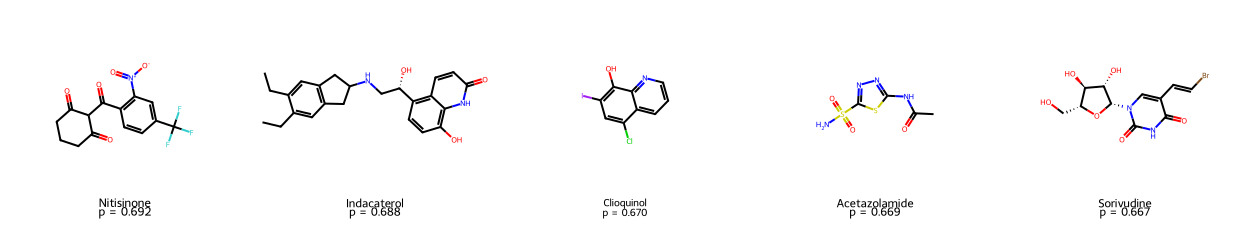

In [7]:
# ── Figure 4 — Molecular structures of top 5 candidates ─────────────────────
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
from PIL import Image
import io

top5     = df_druglike.head(5).copy()
mol_list = []
for _, row in top5.iterrows():
    m = Chem.MolFromSmiles(row['smiles'])
    if m is not None:
        mol_list.append((m, row['drug_name'].title(), round(row['prob_ensemble'], 3)))

if mol_list:
    n      = len(mol_list)
    W, H   = 250, 230

    drawer_opts = rdMolDraw2D.MolDrawOptions()
    drawer_opts.addStereoAnnotation = True
    drawer_opts.padding             = 0.12

    # Save PNG (high-res via PIL resize)
    grid_img = Draw.MolsToGridImage(
        [m for m, _, _ in mol_list],
        molsPerRow=n,
        subImgSize=(W, H),
        useSVG=False,
        legends=[f"{name}\np = {prob:.3f}" for _, name, prob in mol_list],
    )
    out_png = FIG_DIR / 'figure_4_molecular_structures.png'
    if hasattr(grid_img, 'save'):
        scale = 300 / 72
        new_w = int(grid_img.width  * scale)
        new_h = int(grid_img.height * scale)
        hires = grid_img.resize((new_w, new_h), Image.LANCZOS)
        hires.save(str(out_png))
        print(f"  Saved: figure_4_molecular_structures.png  ({new_w}x{new_h} px)")

    # Save SVG grid — MolsToGridImage may return str or IPython.display.SVG
    svg_result = Draw.MolsToGridImage(
        [m for m, _, _ in mol_list],
        molsPerRow=n,
        subImgSize=(W, H),
        useSVG=True,
        legends=[f"{name}\np = {prob:.3f}" for _, name, prob in mol_list],
    )
    # Extract raw SVG string regardless of return type
    if hasattr(svg_result, 'data'):
        svg_str = svg_result.data        # IPython.display.SVG in Jupyter
    else:
        svg_str = str(svg_result)        # plain str outside Jupyter

    out_svg = FIG_DIR / 'figure_4_molecular_structures.svg'
    with open(out_svg, 'w') as f:
        f.write(svg_str)
    print(f"  Saved: figure_4_molecular_structures.svg")

    display(grid_img)
    MAIN_FIGS['Figure 4'] = 'figure_4_molecular_structures'
else:
    print("No valid molecules — re-run nb02 to generate repurposing_candidates.csv")

## Figure 5 — SHAP feature importance

**Main figure.** SHAP beeswarm plot showing the top 15 most influential ECFP4 fingerprint bits for the Random Forest classifier.

Computing SHAP values (interventional, probability output)...


100%|===================| 995/1000 [08:17<00:02]        

SHAP array: (500, 2048)  |  mean|SHAP| range: 0.0153
  Saved: figure_5_shap_importance.png / .svg


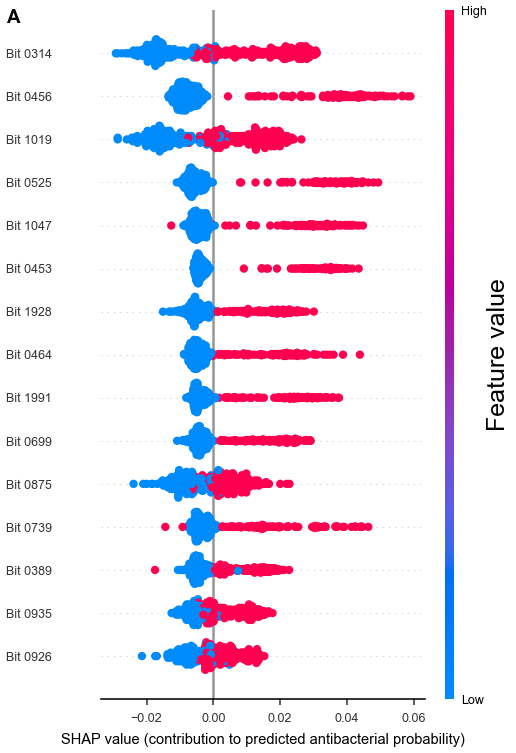

In [8]:
# ── Figure 5 — SHAP feature importance ──────────────────────────────────────
# Single-column width (3.5 in). Use interventional SHAP with model_output="probability"
# to get physically meaningful values (delta probability, not log-odds or raw margin).
import shap

print("Computing SHAP values (interventional, probability output)...")

X_train_np = np.asarray(X_train, dtype=np.float64)
X_test_np  = np.asarray(X_test,  dtype=np.float64)

# Random background (200 samples) and random explain set (500 samples)
rng    = np.random.default_rng(SEED)
bg_idx = rng.choice(X_train_np.shape[0], size=200, replace=False)
ex_idx = rng.choice(X_test_np.shape[0],  size=500, replace=False)
background = X_train_np[bg_idx]
X_explain  = X_test_np[ex_idx]

explainer = shap.TreeExplainer(
    rf,
    data=background,
    feature_perturbation="interventional",
    model_output="probability",
)
shap_vals = explainer.shap_values(X_explain, check_additivity=False)

# Handle all SHAP output formats robustly
if isinstance(shap_vals, list):
    sv = np.asarray(shap_vals[1])          # older shap: [class0, class1]
elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    sv = shap_vals[:, :, 1]               # newer shap: (samples, features, classes)
else:
    sv = np.asarray(shap_vals)

assert sv.ndim == 2, f"Expected 2D SHAP array, got shape {sv.shape}"
assert sv.shape == X_explain.shape, f"Shape mismatch: SHAP {sv.shape} vs X {X_explain.shape}"
print(f"SHAP array: {sv.shape}  |  mean|SHAP| range: {np.abs(sv).mean(axis=0).max():.4f}")

# summary_plot creates its own figure — pass plot_size as (w, h) tuple
shap.summary_plot(
    sv, X_explain,
    feature_names=[f"Bit {i:04d}" for i in range(X_train_np.shape[1])],
    max_display=15,
    show=False,
    plot_size=(3.5, 5.0),
)

fig_shap = plt.gcf()
for ax in fig_shap.axes:
    ax.tick_params(labelsize=6)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
# SHAP values are delta-probability contributions (interventional, model_output="probability")
fig_shap.axes[0].set_xlabel('SHAP value (contribution to predicted antibacterial probability)', fontsize=7)

fig_shap.text(0.01, 0.99, 'A', fontsize=9, fontweight='bold', va='top', ha='left',
              transform=fig_shap.transFigure)

plt.tight_layout(pad=0.3)
fig_shap.savefig(FIG_DIR / 'figure_5_shap_importance.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
fig_shap.savefig(FIG_DIR / 'figure_5_shap_importance.svg', bbox_inches='tight', pad_inches=0.04)
MAIN_FIGS['Figure 5'] = 'figure_5_shap_importance'
print("  Saved: figure_5_shap_importance.png / .svg")
plt.show()

---
## Supplementary Figures

The following figures are designated **Supplementary** material. They provide supporting methodological detail not shown in the main text.

## Supplementary Figure S1 — MLP training dynamics

**Supplementary figure.** Training loss, validation ROC-AUC, and validation PRC-AUC of the deep MLP over 60 epochs. Dashed lines indicate RF baseline performance.

  Loaded training history from training_history.npz (38 epochs)
  Saved: figure_S1_mlp_training_curves.png / .svg


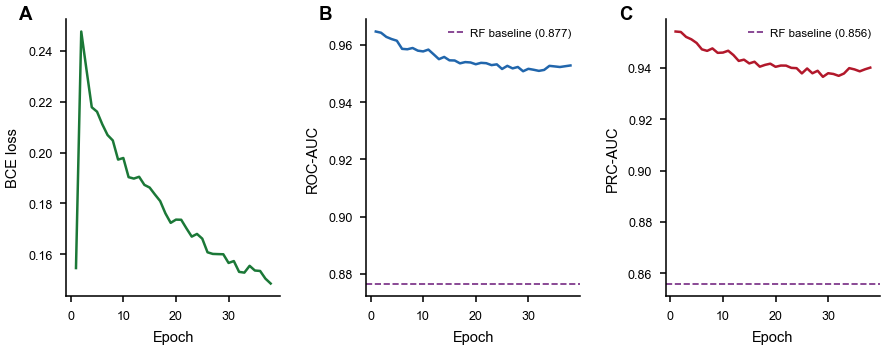

In [9]:
# ── Supplementary Figure S1 — MLP training curves ───────────────────────────
# Uses train_losses / val_aucs / val_prcs from nb02 if in same session,
# otherwise loads from checkpoints/training_history.npz saved by nb02.

try:
    _data_ok = len(train_losses) > 0
except NameError:
    _data_ok = False

if not _data_ok:
    _hist_path = CKPT_DIR / 'training_history.npz'
    if _hist_path.exists():
        _hist = np.load(_hist_path, allow_pickle=True)
        train_losses     = _hist['train_losses'].tolist()
        val_aucs         = _hist['val_aucs'].tolist()
        val_prcs         = _hist['val_prcs'].tolist()
        baseline_results = _hist['baseline_results'].item()
        _data_ok = len(train_losses) > 0
        print(f"  Loaded training history from {_hist_path.name} ({len(train_losses)} epochs)")

if _data_ok:
    fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4),
                              gridspec_kw={'wspace': 0.40})
    epochs = np.arange(1, len(train_losses) + 1)

    axes[0].plot(epochs, train_losses, color=C['mlp'],  lw=1.2, zorder=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')
    add_panel_label(axes[0], 'A', x=-0.22)

    axes[1].plot(epochs, val_aucs, color=C['active'], lw=1.2, zorder=3)
    axes[1].axhline(baseline_results['roc_auc'], color=C['rf'],  ls='--', lw=0.8,
                    label=f"RF baseline ({baseline_results['roc_auc']:.3f})")
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
    axes[1].legend(fontsize=5.5)
    add_panel_label(axes[1], 'B', x=-0.22)

    axes[2].plot(epochs, val_prcs, color=C['inactive'], lw=1.2, zorder=3)
    axes[2].axhline(baseline_results['prc_auc'], color=C['rf'], ls='--', lw=0.8,
                    label=f"RF baseline ({baseline_results['prc_auc']:.3f})")
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('PRC-AUC')
    axes[2].legend(fontsize=5.5)
    add_panel_label(axes[2], 'C', x=-0.22)

    fig.savefig(FIG_DIR / 'figure_S1_mlp_training_curves.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
    fig.savefig(FIG_DIR / 'figure_S1_mlp_training_curves.svg', bbox_inches='tight', pad_inches=0.04)
    SUPP_FIGS['Figure S1'] = 'figure_S1_mlp_training_curves'
    print("  Saved: figure_S1_mlp_training_curves.png / .svg")
    plt.show()
else:
    print("  Training history not available.")
    print("  Run nb02 in full — it saves checkpoints/training_history.npz.")

## Supplementary Figure S2 — ChemBERTa fine-tuning loss

**Supplementary figure.** Training and validation cross-entropy loss during ChemBERTa-zinc fine-tuning. The vertical dotted line marks the best checkpoint selected by early stopping.

  Saved: figure_S2_chemberta_loss.png / .svg


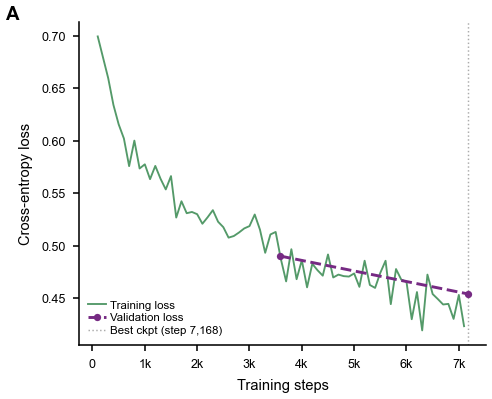

In [10]:
# ── Supplementary Figure S2 — ChemBERTa fine-tuning loss ────────────────────
import glob

# Find latest checkpoint trainer_state.json
log_paths = sorted(glob.glob(str(CKPT_DIR / 'chembert' / 'checkpoint-*' / 'trainer_state.json')))
TRAINER_LOG = Path(log_paths[-1]) if log_paths else None

if TRAINER_LOG and TRAINER_LOG.exists():
    with open(TRAINER_LOG) as f:
        state = json.load(f)
    history    = state.get('log_history', [])
    train_loss = [(h['step'], h['loss'])      for h in history if 'loss'      in h and 'eval_loss' not in h]
    eval_loss  = [(h['step'], h['eval_loss']) for h in history if 'eval_loss' in h]

    fig, ax = plt.subplots(figsize=(3.5, 2.8))
    if train_loss:
        s, v = zip(*train_loss)
        ax.plot(s, v, color=C['mlp'], lw=0.9, alpha=0.75, label='Training loss', zorder=3)
    if eval_loss:
        s, v = zip(*eval_loss)
        ax.plot(s, v, color=C['rf'], lw=1.4, ls='--', marker='o', ms=3.5,
                markeredgewidth=0, label='Validation loss', zorder=4)
        best_step = s[int(np.argmin(v))]
        ax.axvline(best_step, color=C['neutral'], lw=0.7, ls=':', alpha=0.8,
                   label=f'Best ckpt (step {best_step:,})', zorder=2)
    ax.set_xlabel('Training steps')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(fontsize=5.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}k' if x>=1000 else str(int(x))))
    add_panel_label(ax, 'A', x=-0.18)

    fig.savefig(FIG_DIR / 'figure_S2_chemberta_loss.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
    fig.savefig(FIG_DIR / 'figure_S2_chemberta_loss.svg', bbox_inches='tight', pad_inches=0.04)
    SUPP_FIGS['Figure S2'] = 'figure_S2_chemberta_loss'
    print("  Saved: figure_S2_chemberta_loss.png / .svg")
    plt.show()
else:
    print(f"  ChemBERTa trainer log not found in {CKPT_DIR / 'chembert'}")

## Supplementary Figure S3 — Organism-specific model performance

**Supplementary figure.** Per-pathogen Random Forest performance on organism-stratified subsets. Bubble area encodes positive class fraction.

  Saved: figure_S3_organism_performance.png / .svg


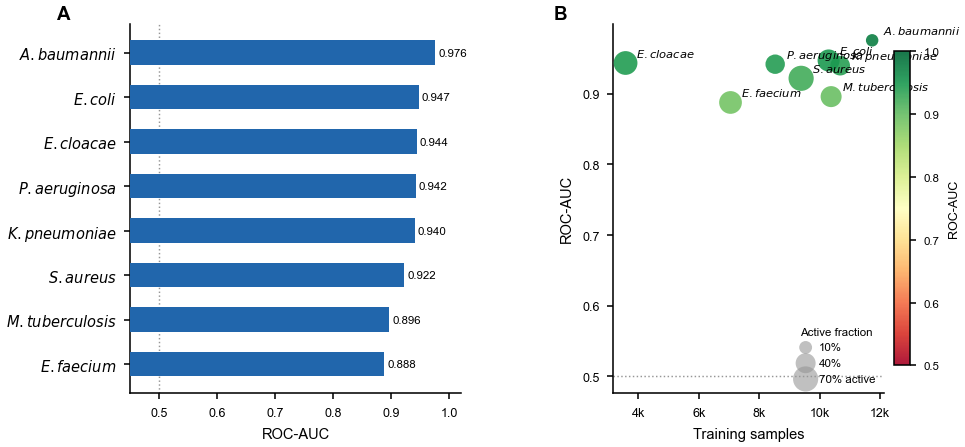

In [11]:
# ── Supplementary Figure S3 — Organism-specific performance ─────────────────
if not df_org.empty and df_org['status'].eq('trained').any():
    df_tr = df_org[df_org['status'] == 'trained'].copy()
    df_tr['short'] = df_tr['organism'].apply(
        lambda x: f"$\\it{{{x.split()[0][0]}. {x.split()[1]}}}$" if len(x.split()) >= 2 else x)
    df_tr = df_tr.sort_values('roc_auc', ascending=True).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2),
                              gridspec_kw={'wspace': 0.46})

    # Panel A: ROC-AUC bar chart per organism
    y_pos = np.arange(len(df_tr))
    hbars = axes[0].barh(y_pos, df_tr['roc_auc'], height=0.55,
                         color=C['active'], edgecolor='none', zorder=3)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(df_tr['short'], fontsize=7)
    axes[0].axvline(0.5, color=C['neutral'], ls=':', lw=0.7, zorder=2)
    axes[0].set_xlabel('ROC-AUC')
    axes[0].set_xlim(0.45, 1.02)
    for bar, val in zip(hbars, df_tr['roc_auc']):
        axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=5.5)
    add_panel_label(axes[0], 'A', x=-0.22)

    # Panel B: training set size vs AUC bubble chart
    # Bubble area encodes active-class fraction (larger = higher fraction of actives)
    active_frac = df_tr['n_active'] / df_tr['n_total']
    bubble_sz   = active_frac * 180 + 20
    sc = axes[1].scatter(df_tr['n_total'], df_tr['roc_auc'],
                         s=bubble_sz, c=df_tr['roc_auc'],
                         cmap='RdYlGn', vmin=0.5, vmax=1.0,
                         edgecolors='none', alpha=0.9, zorder=3)
    # Offset labels to reduce overlap
    for _, row in df_tr.iterrows():
        axes[1].annotate(row['short'], xy=(row['n_total'], row['roc_auc']),
                         xytext=(5, 3), textcoords='offset points', fontsize=5.5,
                         ha='left')
    cb = fig.colorbar(sc, ax=axes[1], shrink=0.85, pad=0.03)
    cb.set_label('ROC-AUC', fontsize=6); cb.ax.tick_params(labelsize=5.5)
    axes[1].axhline(0.5, color=C['neutral'], ls=':', lw=0.7, zorder=2)
    axes[1].set_xlabel('Training samples')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x,_: f'{int(x/1000)}k' if x>=1000 else str(int(x))))
    add_panel_label(axes[1], 'B', x=-0.22)

    # Bubble size legend (3 reference sizes: 10%, 40%, 70% active fraction)
    for frac, label in [(0.10, '10%'), (0.40, '40%'), (0.70, '70% active')]:
        axes[1].scatter([], [], s=frac*180+20, color=C['neutral'], alpha=0.6,
                        label=label, edgecolors='none')
    axes[1].legend(title='Active fraction', fontsize=5.5, title_fontsize=5.5,
                   loc='lower right', handletextpad=0.4, labelspacing=0.5)

    fig.savefig(FIG_DIR / 'figure_S3_organism_performance.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
    fig.savefig(FIG_DIR / 'figure_S3_organism_performance.svg', bbox_inches='tight', pad_inches=0.04)
    SUPP_FIGS['Figure S3'] = 'figure_S3_organism_performance'
    print("  Saved: figure_S3_organism_performance.png / .svg")
    plt.show()
else:
    print("  Organism results not found — run nb02 organism-specific section first.")

## Supplementary Figure S4 — ADMET properties of top candidates

**Supplementary figure.** Distribution of key drug-likeness descriptors for the top 50 ranked non-antibiotic drug-like candidates. Vertical dashed lines indicate Lipinski Ro5 and Veber thresholds. Panel H: QED score versus ensemble probability, coloured by molecular weight.

  Saved: figure_S4_admet_properties.png / .svg


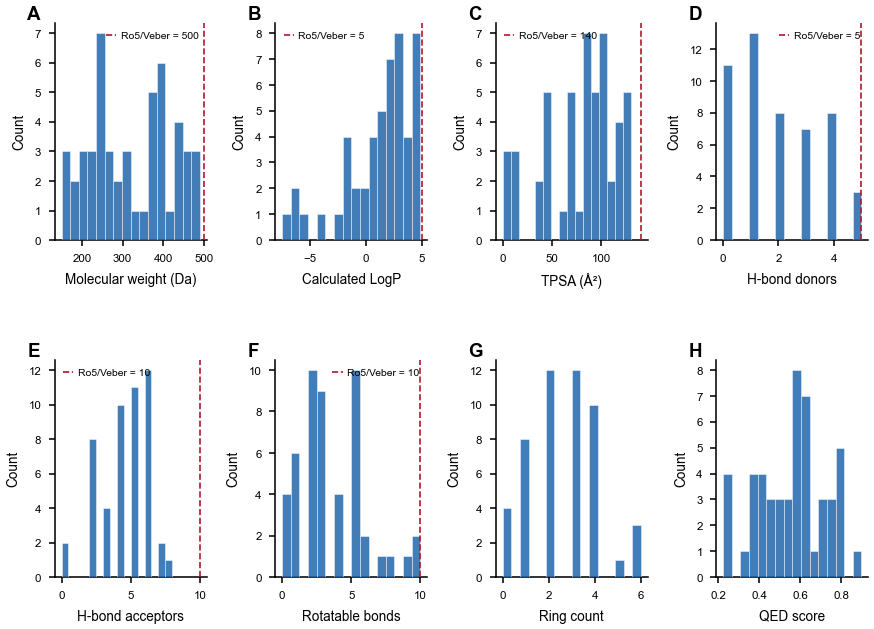

In [12]:
# ── Supplementary Figure S4 — ADMET properties ──────────────────────────────
ADMET_COLS = ['mw', 'logp', 'tpsa', 'hbd', 'hba', 'rot_bonds', 'rings', 'qed']
ADMET_LABS = {
    'mw':       'Molecular weight (Da)',
    'logp':     'Calculated LogP',
    'tpsa':     'TPSA (Å²)',
    'hbd':      'H-bond donors',
    'hba':      'H-bond acceptors',
    'rot_bonds':'Rotatable bonds',
    'rings':    'Ring count',
    'qed':      'QED score',
}
ADMET_REFS = {'mw': 500, 'logp': 5, 'tpsa': 140, 'hbd': 5, 'hba': 10, 'rot_bonds': 10}

present = [c for c in ADMET_COLS if c in df_druglike.columns]

if len(present) >= 4:
    top50 = df_druglike.head(50)
    n_col = 4
    n_row = int(np.ceil(len(present) / n_col))

    fig, axes = plt.subplots(n_row, n_col,
                              figsize=(7.0, 2.4 * n_row),
                              gridspec_kw={'hspace': 0.55, 'wspace': 0.45})
    axes_flat = axes.flatten() if n_row > 1 else axes

    for idx, col in enumerate(present):
        ax  = axes_flat[idx]
        vals = top50[col].dropna()
        ax.hist(vals, bins=16, color=C['active'], edgecolor='white',
                linewidth=0.25, alpha=0.85, zorder=3)
        if col in ADMET_REFS:
            ax.axvline(ADMET_REFS[col], color=C['inactive'], ls='--', lw=0.8,
                       label=f'Ro5/Veber = {ADMET_REFS[col]}', zorder=4)
            ax.legend(fontsize=5.0, handlelength=1.0)
        ax.set_xlabel(ADMET_LABS.get(col, col), fontsize=6.5)
        ax.set_ylabel('Count', fontsize=6.5)
        ax.tick_params(labelsize=5.5)
        add_panel_label(ax, chr(65 + idx), x=-0.18, y=1.08)

    # Hide unused axes
    for idx in range(len(present), len(axes_flat)):
        axes_flat[idx].set_visible(False)

    fig.savefig(FIG_DIR / 'figure_S4_admet_properties.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
    fig.savefig(FIG_DIR / 'figure_S4_admet_properties.svg', bbox_inches='tight', pad_inches=0.04)
    SUPP_FIGS['Figure S4'] = 'figure_S4_admet_properties'
    print("  Saved: figure_S4_admet_properties.png / .svg")
    plt.show()
else:
    print(f"  ADMET columns not found ({present}) — re-run nb02.")

## Supplementary Figure S5 — Model performance comparison

**Supplementary figure.** ROC-AUC and PRC-AUC comparison between Random Forest and deep MLP classifiers on the held-out test set.

  Saved: figure_S5_model_comparison.png / .svg


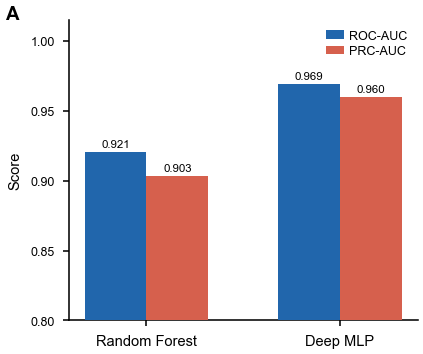

In [13]:
# ── Supplementary Figure S5 — Model comparison ──────────────────────────────
models     = ['Random Forest', 'Deep MLP']
roc_scores = [rf_roc,  mlp_roc]
prc_scores = [rf_prc,  mlp_prc]

fig, ax = plt.subplots(figsize=(3.0, 2.6))
x  = np.arange(2)
w  = 0.32
b1 = ax.bar(x - w/2, roc_scores, w, color=C['active'],   label='ROC-AUC', edgecolor='none', zorder=3)
b2 = ax.bar(x + w/2, prc_scores, w, color=C['ensemble'], label='PRC-AUC', edgecolor='none', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=7)
ax.set_ylim(0.80, 1.015)   # headroom for value labels above bars
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.set_ylabel('Score')
ax.legend(fontsize=6)

# value labels on bars
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom', fontsize=5.5)

add_panel_label(ax, 'A', x=-0.18)

fig.savefig(FIG_DIR / 'figure_S5_model_comparison.png', dpi=300, bbox_inches='tight', pad_inches=0.04)
fig.savefig(FIG_DIR / 'figure_S5_model_comparison.svg', bbox_inches='tight', pad_inches=0.04)
SUPP_FIGS['Figure S5'] = 'figure_S5_model_comparison'
print("  Saved: figure_S5_model_comparison.png / .svg")
plt.show()

## Figure registry

Run the cell below to print all saved figure names.

In [14]:
print("\n── Main Figures")
for k, v in sorted(MAIN_FIGS.items()):
    print(f"  {k:12s}: {v}.png / .svg")
print("\n── Supplementary Figures")
for k, v in sorted(SUPP_FIGS.items()):
    print(f"  {k:12s}: {v}.png / .svg")
print()
import os
saved = sorted(os.listdir(FIG_DIR))
print(f"Files in figures/ : {len(saved)}")
for f in saved: print(f"  {f}")


── Main Figures
  Figure 1    : figure_1_dataset_overview.png / .svg
  Figure 2    : figure_2_model_performance.png / .svg
  Figure 3    : figure_3_repurposing_candidates.png / .svg
  Figure 4    : figure_4_molecular_structures.png / .svg
  Figure 5    : figure_5_shap_importance.png / .svg

── Supplementary Figures
  Figure S1   : figure_S1_mlp_training_curves.png / .svg
  Figure S2   : figure_S2_chemberta_loss.png / .svg
  Figure S3   : figure_S3_organism_performance.png / .svg
  Figure S4   : figure_S4_admet_properties.png / .svg
  Figure S5   : figure_S5_model_comparison.png / .svg

Files in figures/ : 29
  .DS_Store
  .ipynb_checkpoints
  confusion_matrix.png
  eda.png
  evaluation_curves.png
  figure_1_dataset_overview.png
  figure_1_dataset_overview.svg
  figure_2_model_performance.png
  figure_2_model_performance.svg
  figure_3_repurposing_candidates.png
  figure_3_repurposing_candidates.svg
  figure_4_molecular_structures.svg
  figure_5_shap_importance.png
  figure_5_shap_impo